In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df=pd.read_excel("../data/raw/Online Retail.xlsx")

In [2]:
display(df.head(5),df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


None

In [3]:
display(df.isna().sum(), df['Country'].value_counts())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [4]:
df['CustomerID'] = df['CustomerID'].fillna('Unknown').astype(str)
df['Description'] = df['Description'].fillna('No description')
df['InvoiceTime'] = df['InvoiceDate'].dt.time
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'].dt.date)

df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['total_price'] = df_clean['UnitPrice'] * df_clean['Quantity']
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

df_clean["log_Quantity"] = np.log1p(df_clean["Quantity"])
df_clean["log_total_price"] = np.log1p(df_clean["total_price"])
df_clean["log_UnitPrice"] = np.log1p(df_clean["UnitPrice"])
df_clean['Quarters']= df_clean['InvoiceDate'].dt.to_period("Q")





In [5]:
numeric_cols = ['Quantity','UnitPrice','total_price',"log_Quantity","log_total_price","log_UnitPrice"]

desc = df_clean[numeric_cols].describe().T
desc['variance'] = df_clean[numeric_cols].var()
desc['skewness'] = df_clean[numeric_cols].skew()
desc['kurtosis'] = df_clean[numeric_cols].kurtosis()
desc['cv'] = desc['std']/desc['mean']
display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,cv
Quantity,530104.0,10.542,155.524,1.000,1.000,3.000,10.000,80995.000,24187.753,471.728,236462.343,14.753
UnitPrice,530104.0,3.908,35.916,0.001,1.250,2.080,4.130,13541.330,1289.936,206.088,62483.143,9.191
total_price,530104.0,20.122,270.357,0.001,3.750,9.900,17.700,168469.600,73092.769,506.706,297651.661,13.436
log_Quantity,530104.0,1.710,0.989,0.693,0.693,1.386,2.398,11.302,0.979,1.025,1.077,0.578
log_total_price,530104.0,2.331,1.019,0.001,1.558,2.389,2.929,12.035,1.039,0.561,0.945,0.437
log_UnitPrice,530104.0,1.240,0.644,0.001,0.811,1.125,1.635,9.514,0.415,1.111,3.643,0.519


In [6]:
print("\n TOTAL PRICE BY COUNTRY SUMMARY STATISTTICS")
display(df_clean.groupby('Country')['total_price']
    .agg(['sum','mean','median','min','max','std'])
    .round(2)
    .sort_values(by='sum', ascending= False))

print("\n TOTAL PRICE BY QUATERS")
display(df_clean.groupby('Quarters')['total_price']
       .agg(['sum','mean','median','min','max','std'])
       .round(2)
       .sort_values(by='Quarters', ascending= False))


 TOTAL PRICE BY COUNTRY SUMMARY STATISTTICS


,sum,mean,median,min,max,std
Country,,,,,,
United Kingdom,9025222.08,18.60,8.42,0.00,168469.60,281.28
Netherlands,285446.34,121.00,91.80,0.39,4992.00,164.05
EIRE,283453.96,35.93,17.40,0.42,2365.20,84.60
Germany,228867.14,25.32,17.00,0.39,876.00,35.46
France,209715.11,24.95,16.60,0.29,4161.06,74.09
Australia,138521.31,117.19,66.00,0.42,1718.40,159.90
Spain,61577.11,24.79,15.00,0.21,1350.00,70.35
Switzerland,57089.90,29.04,17.70,0.42,360.00,35.24
Belgium,41196.34,20.28,16.60,2.50,165.00,15.25



 TOTAL PRICE BY QUATERS


,sum,mean,median,min,max,std
Quarters,,,,,,
2011Q4,3303268.31,19.69,8.50,0.06,168469.60,417.13
2011Q3,2536949.74,20.73,10.20,0.00,11062.06,79.16
2011Q2,2070084.54,20.45,10.20,0.00,38970.00,141.48
2011Q1,1932635.81,19.88,9.90,0.18,77183.60,255.92
2010Q4,823746.14,19.86,8.47,0.14,13541.33,97.35


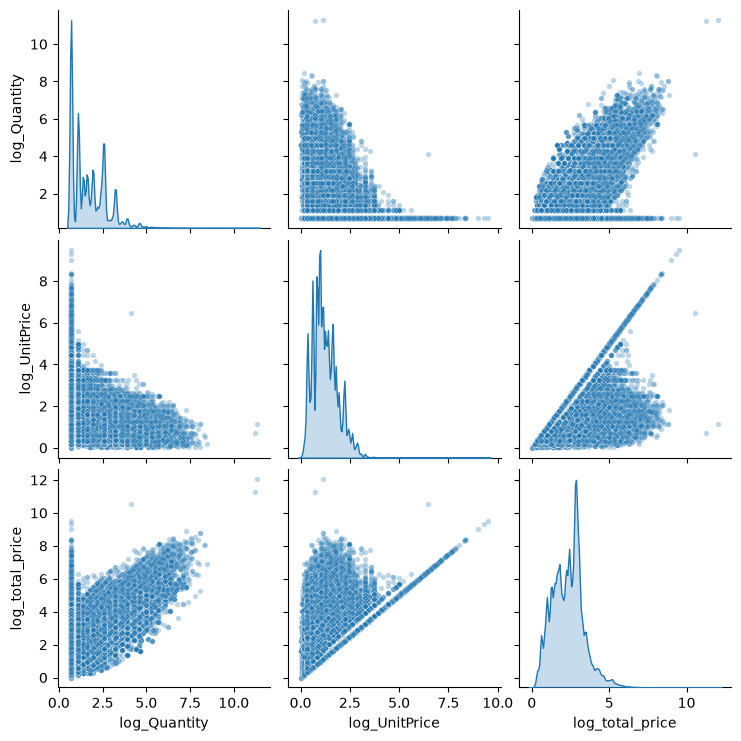

In [7]:
sns.pairplot(
    df_clean[["log_Quantity", "log_UnitPrice", "log_total_price"]],
    kind="scatter",
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 15},  # Alpha transparency helps reduce overplotting
)
plt.show()

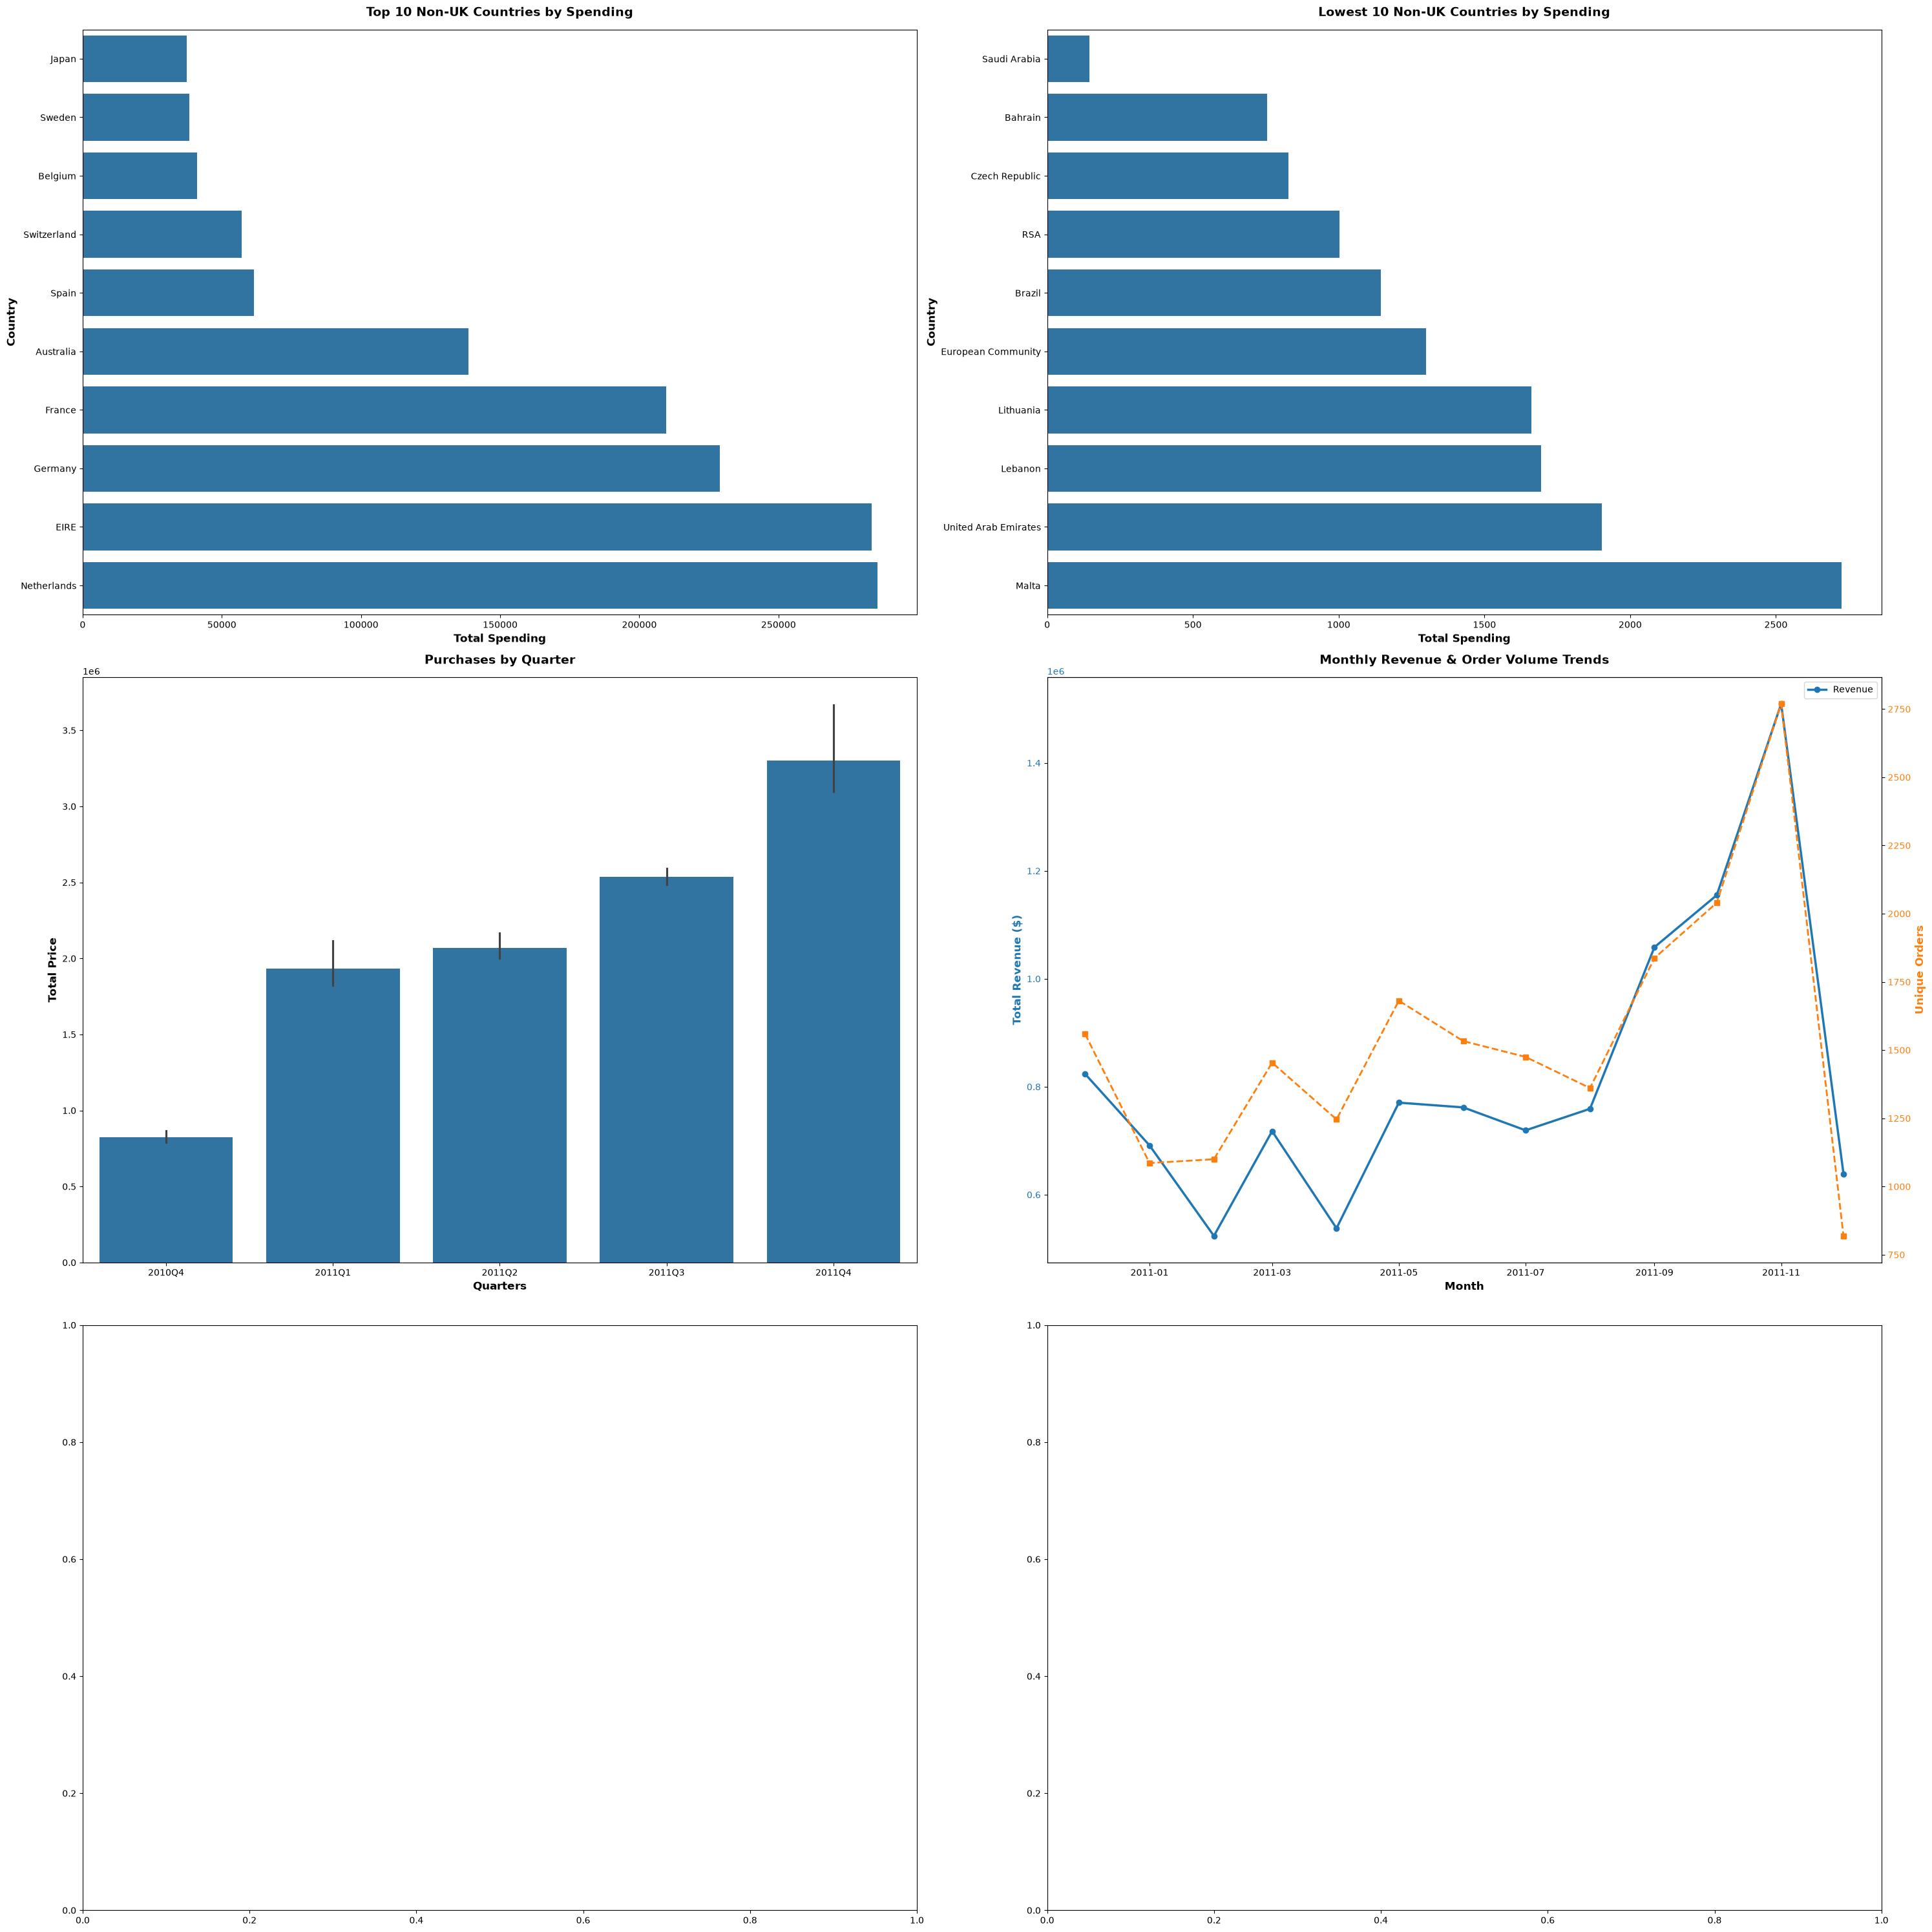

In [65]:
fig, axes = plt.subplots(3,2, figsize=(30,30))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()
def plot_country_spending(df, ax, n=10, ascending=False, log_scale=False):
    spend_df = (
        df[(df["Country"] != "United Kingdom")]
        .groupby("Country")["total_price"]
        .sum()
        .sort_values(ascending=ascending)
        .head(n)
        .reset_index()
    )

    spend_df = spend_df.sort_values(by="total_price", ascending=True)

    spend_df["Country"] = spend_df["Country"].astype(str)
    
    sns.barplot(data=spend_df, x="total_price", y="Country",ax=ax)

    label_type = "Lowest" if ascending else "Top"
    ax.set_title(f"{label_type} {n} Non-UK Countries by Spending", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Total Spending",fontsize=12, fontweight='bold')
    ax.set_ylabel("Country",fontsize=12, fontweight='bold')
    #ax.tick_params(axis="x", rotation=90)

    if log_scale:
        ax.set_xscale("log")

    return ax
plot_country_spending(df_clean,ax1)
plot_country_spending(df_clean,ax2, ascending=True)


sns.barplot(
    data=df_clean,
    x='Quarters',
    y='total_price',
    estimator= np.sum,
    ax=ax3
)
ax3.set_title("Purchases by Quarter", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Quarters",fontsize=12, fontweight='bold')
ax3.set_ylabel("Total Price",fontsize=12, fontweight='bold')



color1='#1f77b4'
color2='#ff7f0e'

monthly_data = df_clean.groupby('YearMonth').agg(
    TotalRevenue=('total_price', 'sum'),
    OrderCount=('InvoiceNo', 'nunique')
).reset_index()

monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()
ax4.set_xlabel('Month', fontsize=12, fontweight='bold')
ax4.set_ylabel('Total Revenue ($)', color=color1, fontsize=12, fontweight='bold')
ax4.plot(monthly_data['YearMonth'], monthly_data['TotalRevenue'], 
         color=color1, marker='o', linewidth=2.5, label='Revenue')
ax4.tick_params(axis='y', labelcolor=color1)


# Dual Axis for Order Count (Line 2)
ax4_twin = ax4.twinx()  
ax4_twin.set_ylabel('Unique Orders', color=color2, fontsize=12, fontweight='bold')
ax4_twin.plot(monthly_data['YearMonth'], monthly_data['OrderCount'], 
              color=color2, marker='s', linestyle='--', linewidth=2, label='Orders')
ax4_twin.tick_params(axis='y', labelcolor=color2)

ax4.set_title('Monthly Revenue & Order Volume Trends', fontsize=14, fontweight='bold', pad=15)
ax4.legend()


plt.tight_layout()
plt.show()

In [50]:
df_clean.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceTime,total_price,log_Quantity,log_total_price,log_UnitPrice,Quarters
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,08:26:00,15.30,1.945910,2.791165,1.266948,2010Q4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34,1.945910,3.060583,1.479329,2010Q4
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,08:26:00,22.00,2.197225,3.135494,1.321756,2010Q4
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34,1.945910,3.060583,1.479329,2010Q4
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34,1.945910,3.060583,1.479329,2010Q4


In [58]:
df_clean['InvoiceNo'].value_counts()

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
          ... 
581479       1
581483       1
581487       1
581491       1
581566       1
Name: count, Length: 19960, dtype: int64

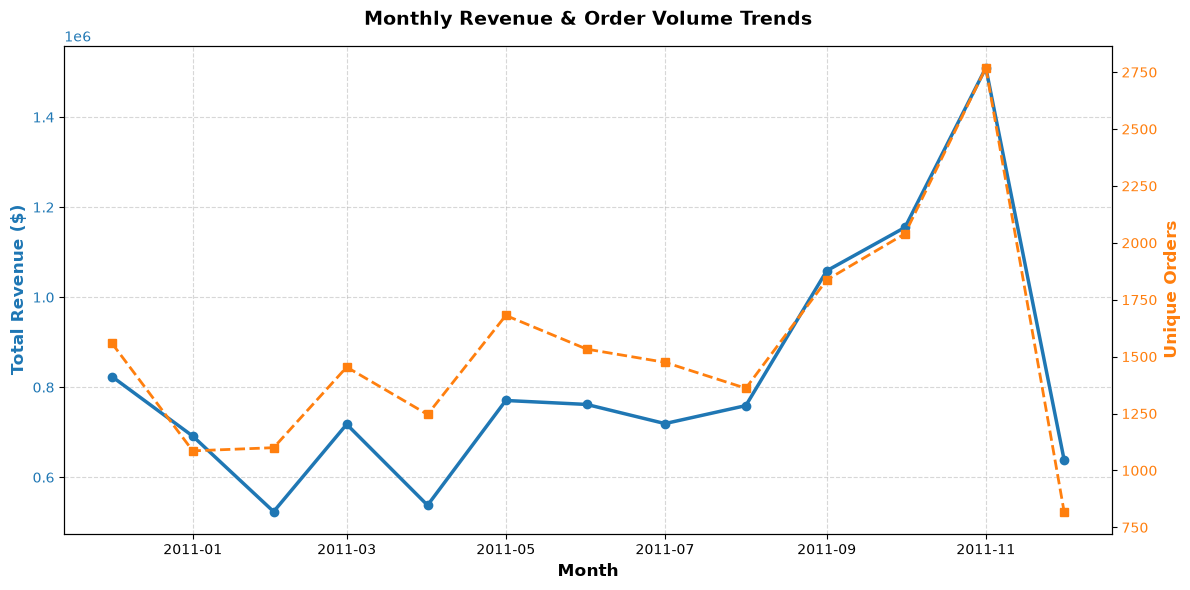

In [60]:
# Resample by Month


# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Revenue (Line 1)
